# Assignment 2 — Sequence Language Models (GPU Edition, direct Cosmopedia access)

**Name:** *Zhang Jingxuan*   **Number:** *A0326409A*   **Date:** 2025-09-10

- Mandate the use of **HuggingFace Cosmopedia** (or its 100k subset) as the sole source corpus; do not use any sample/toy texts.
- Automatically prefer **GPU (CUDA)**; fall back to **CPU** if no GPU is detected.
- Include DataLoader and CUDA optimizations (e.g., `pin_memory`, `num_workers`, TF32).

## 1. Environment and Devices (GPU Preferred)

In [91]:
from tqdm.auto import tqdm
import sys, os, math, time, random, re
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cuda":
    try:
        print("GPU:", torch.cuda.get_device_name(0))
        # CUDA performance tweaks
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
    except Exception as e:
        print("GPU info error:", e)

Python: 3.9.19 (main, May  6 2024, 20:12:36) [MSC v.1916 64 bit (AMD64)]
PyTorch: 2.5.1+cu121
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Load Corpus from HuggingFace Cosmopedia (Mandatory)

> **Streaming** is enabled by default, with dataset size controlled by entry count or character limit. Use `cosmopedia-100k` first to validate the workflow.


In [ ]:
from datasets import load_dataset
from pathlib import Path

#  Note: comment replaced from Chinese
HF_DATASET_NAME = "HuggingFaceTB/cosmopedia"      #   "HuggingFaceTB/cosmopedia-100k"
HF_CONFIG = "stories"                              #  auto_math_text / khanacademy / openstax / stanford / stories / web_samples_v1 / web_samples_v2 / wikihow
HF_SPLIT = "train"
HF_STREAMING = True                                #   True
HF_SAMPLE_LIMIT = 2000000                           #  （；）
HF_MAX_CHARS = 2000000                     #  （）
HF_TEXT_FIELD = "text"
HF_FILTER_FORMAT = None                            #  :  -> "textbook"

def load_corpus_from_hf(
    dataset_name=HF_DATASET_NAME, config=HF_CONFIG, split=HF_SPLIT,
    streaming=HF_STREAMING, sample_limit=HF_SAMPLE_LIMIT, max_chars=HF_MAX_CHARS,
    text_field=HF_TEXT_FIELD, filter_format=HF_FILTER_FORMAT
):
    if streaming:
        ds = load_dataset(dataset_name, config, split=split, streaming=True)
        total_chars, total_rows = 0, 0
        texts = []
        for ex in ds:
            if filter_format is not None and ex.get("format", None) != filter_format:
                continue
            t = ex.get(text_field, None)
            if not t:
                continue
            texts.append(t.strip())
            total_rows += 1
            total_chars += len(t)
            if sample_limit is not None and total_rows >= sample_limit:
                break
            if max_chars is not None and total_chars >= max_chars:
                break
        raw_text = "\n\n".join(texts)
        return raw_text, dict(rows=total_rows, chars=len(raw_text), streaming=True)
    else:
        ds = load_dataset(dataset_name, config, split=split)
        if filter_format is not None and "format" in ds.column_names:
            ds = ds.filter(lambda ex: ex.get("format", None) == filter_format)
        if sample_limit is not None:
            ds = ds.select(range(min(sample_limit, len(ds))))
        texts = [t.strip() for t in ds[text_field] if isinstance(t, str)]
        raw_text = "\n\n".join(texts)
        if max_chars is not None and len(raw_text) > max_chars:
            raw_text = raw_text[:max_chars]
        return raw_text, dict(rows=len(texts), chars=len(raw_text), streaming=False)

print("Loading Cosmopedia:", HF_DATASET_NAME, "| config:", HF_CONFIG, "| split:", HF_SPLIT)
raw_text, info = load_corpus_from_hf()
print(f"Fetched rows={info['rows']}  chars={info['chars']}  streaming={info['streaming']}")

save_dir = Path.cwd() / "data"
save_dir.mkdir(parents=True, exist_ok=True)  #   data 
out_txt = save_dir / "cosmopedia_corpus.txt"
out_txt.write_text(raw_text, encoding="utf-8")
print("Saved concatenated corpus to:", out_txt.resolve())

Loading Cosmopedia: HuggingFaceTB/cosmopedia | config: stories | split: train


In [79]:
# Quick smoke test: use the first 2000 characters from the saved corpus file
from pathlib import Path

corpus_path = Path("data/cosmopedia_corpus.txt")
if not corpus_path.exists():
    raise FileNotFoundError("data/cosmopedia_corpus.txt not found. Please run the dataset loading cell first.")

full_text = corpus_path.read_text(encoding="utf-8")
raw_text = full_text[:20000]  # override the global raw_text used by training
print(f"[Smoke Test] Using the first 20000 characters from: {corpus_path}")
print("Length of raw_text:", len(raw_text))
print("Preview (first 400 chars):\n", raw_text[:400].replace("\n", "\\n"))

[Smoke Test] Using the first 20000 characters from: data\cosmopedia_corpus.txt
Length of raw_text: 20000
Preview (first 400 chars):
 Once upon a time, in a village called Kiwiland, there lived two best friends named Kiwi and Koala. They loved exploring the world around them and learning new things every day! One day, they stumbled upon a magical forest full of vibrant colors and fascinating creatures. As they ventured deeper into the forest, they met Torty, a wise old turtle who was known to have answers to all questions.\n\nKiwi


## 3. Training Configuration and Ablation Table (GPU-Friendly Defaults)

In [80]:
import pandas as pd

DEFAULTS = dict(
    tokenizer="char",   # "char" | "word"
    seq_len=256,
    emb_dim=256,
    hidden=256,
    num_layers=1,
    nhead=4,
    tfm_layers=2,
    dropout=0.1,
    batch_size=32,
    epochs=30,
    lr=3e-4,
    clip=1.0,
    seed=42,
    device=("cuda" if torch.cuda.is_available() else "cpu"),
    log_every=50,
    max_tokens=None,
)

ORIGINAL_ABLATIONS = [
    # 1) LSTM, char, seq_len=256, dropout=0.0 vs 0.2（dropout comparison）
    dict(model="lstm",        tokenizer="char", seq_len=256, dropout=0.0, epochs=30, batch_size=32),
    dict(model="lstm",        tokenizer="char", seq_len=256, dropout=0.2, epochs=30, batch_size=32),

    # 2) Transformer, char, context length comparison：128 vs 256
    dict(model="transformer", tokenizer="char", seq_len=128, dropout=0.1, epochs=30, batch_size=32),
    dict(model="transformer", tokenizer="char", seq_len=256, dropout=0.1, epochs=30, batch_size=16),

    # 3) tokenization comparison：word vs char（two models）
    dict(model="transformer", tokenizer="word", seq_len=128, dropout=0.1, epochs=30, batch_size=32),
    dict(model="lstm",        tokenizer="word", seq_len=256, dropout=0.2, epochs=30, batch_size=32),
]
FAST_MODE = False

ABLATIONS = [dict(model="transformer", tokenizer="char", seq_len=128, dropout=0.1, epochs=30, batch_size=32)] if FAST_MODE else ORIGINAL_ABLATIONS
OUT_DIR = Path("results"); OUT_DIR.mkdir(exist_ok=True, parents=True)
for ablation in ABLATIONS:
    print(ablation)

# DataLoader tuning (on Windows, if multiprocessing causes issues, set num_workers=0)
NUM_WORKERS = 0            # <- KEY: single-process loader
PIN_MEMORY  = bool(torch.cuda.is_available())  # OK to keep True
print("NUM_WORKERS =", NUM_WORKERS, "| PIN_MEMORY =", PIN_MEMORY)

{'model': 'lstm', 'tokenizer': 'char', 'seq_len': 256, 'dropout': 0.0, 'epochs': 30, 'batch_size': 32}
{'model': 'lstm', 'tokenizer': 'char', 'seq_len': 256, 'dropout': 0.2, 'epochs': 30, 'batch_size': 32}
{'model': 'transformer', 'tokenizer': 'char', 'seq_len': 128, 'dropout': 0.1, 'epochs': 30, 'batch_size': 32}
{'model': 'transformer', 'tokenizer': 'char', 'seq_len': 256, 'dropout': 0.1, 'epochs': 30, 'batch_size': 16}
{'model': 'transformer', 'tokenizer': 'word', 'seq_len': 128, 'dropout': 0.1, 'epochs': 30, 'batch_size': 32}
{'model': 'lstm', 'tokenizer': 'word', 'seq_len': 256, 'dropout': 0.2, 'epochs': 30, 'batch_size': 32}
NUM_WORKERS = 0 | PIN_MEMORY = True


## 4. Utility Functions

In [81]:
def set_seed(seed: int = 42):
    import random, numpy as np, torch
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def save_plot(train_losses, val_losses, out_png):
    plt.figure()
    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="val")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.title("Training / Validation Loss")
    plt.tight_layout(); plt.savefig(out_png); plt.show()

## 5. Tokenizer

In [82]:
class CharTokenizer:
    def __init__(self, text: str):
        chars = sorted(list(set(text)))
        self.stoi = {c:i for i,c in enumerate(chars)}
        self.itos = {i:c for c,i in self.stoi.items()}
        self.vocab_size = len(self.stoi)
    def encode(self, text: str): return [self.stoi[c] for c in text if c in self.stoi]
    def decode(self, ids): return "".join(self.itos[i] for i in ids)

import re as _re
class WordTokenizer:
    WORD_RE = _re.compile(r"\w+|[^\w\s]", _re.UNICODE)
    def __init__(self, text: str, min_freq: int = 1, max_vocab: int = 50000):
        toks = self.WORD_RE.findall(text); freq = {}
        for t in toks: freq[t] = freq.get(t, 0) + 1
        items = sorted(freq.items(), key=lambda x:(-x[1], x[0]))[:max_vocab]
        self.stoi = {tk:i for i,(tk,cnt) in enumerate(items) if cnt >= min_freq}
        self.itos = {i:tk for tk,i in self.stoi.items()}
        self.unk = len(self.stoi); self.stoi["<UNK>"]=self.unk; self.itos[self.unk]="<UNK>"
        self.vocab_size = len(self.stoi)
    def encode(self, text: str):
        return [self.stoi.get(t, self.unk) for t in self.WORD_RE.findall(text)]
    def decode(self, ids): return " ".join(self.itos[i] for i in ids)

## 6. Dataset and Segmentation (80/10/10)

In [83]:
class LMSequenceDataset(Dataset):
    def __init__(self, ids: List[int], seq_len: int):
        self.ids = ids; self.seq_len = seq_len
        self.num_seq = (len(ids) - 1) // seq_len
    def __len__(self): return self.num_seq
    def __getitem__(self, idx):
        s = idx * self.seq_len
        x = torch.tensor(self.ids[s:s+self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[s+1:s+self.seq_len+1], dtype=torch.long)
        return x, y

def split_data(tokens: List[int], ratios=(0.8,0.1,0.1)):
    n=len(tokens); i=int(n*ratios[0]); j=int(n*(ratios[0]+ratios[1])); return tokens[:i], tokens[i:j], tokens[j:]

## 7. Models：LSTM LM and Causal Transformer LM

In [84]:
class LSTMLM(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, hidden=256, num_layers=1, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden, num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers>1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, vocab_size)
    def forward(self, x, hidden=None):
        x=self.embed(x); out, hidden=self.lstm(x, hidden); out=self.drop(out); return self.fc(out), hidden

class CausalTransformer(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, nhead=4, num_layers=2, dropout=0.1, max_len=1024):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, emb_dim)
        self.pos_emb = nn.Embedding(max_len, emb_dim)
        enc_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=nhead,
                                               dim_feedforward=4*emb_dim, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.ln_f = nn.LayerNorm(emb_dim)
        self.fc = nn.Linear(emb_dim, vocab_size)
        self.max_len = max_len
    def forward(self, x):
        B,T=x.size(); pos=torch.arange(0,T,device=x.device).unsqueeze(0).expand(B,T)
        h=self.token_emb(x)+self.pos_emb(pos)
        mask=torch.triu(torch.ones(T,T,device=x.device)*float("-inf"), diagonal=1)
        h=self.encoder(h, mask=mask); h=self.ln_f(h); return self.fc(h)

## 8. Training / Evaluation / Generation

In [85]:
import math, random, time
import torch
import torch.nn as nn

def build_tokenizer(text: str, kind: str):
    if kind == "char":
        return CharTokenizer(text)
    if kind == "word":
        return WordTokenizer(text)
    raise ValueError("tokenizer must be 'char' or 'word'")

def eval_loader(loader, model, criterion, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)[0] if isinstance(model, LSTMLM) else model(x)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1)
            )
            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()
    avg = total_loss / max(1, total_tokens)
    ppl = math.exp(avg) if avg < 20 else float("inf")
    return avg, ppl

def sample_generate(
    model, tok, seq_len: int, device: str,
    max_new_tokens: int = 200,
    temperature: float = 1.0,          # 仍支持温度
    strategy: str = "temperature",     # 'greedy' | 'temperature' | 'topk' | 'topp'
    top_k: int = 50,
    top_p: float = 0.9,
    start_text: str = ""
):
    model.eval()
    ids = tok.encode(start_text) if start_text else [random.randrange(tok.vocab_size)]
    ids = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            x = ids[:, -seq_len:]
            logits = model(x)[0] if isinstance(model, LSTMLM) else model(x)
            logits = logits[:, -1, :]

            if strategy == "greedy":
                next_id = torch.argmax(logits, dim=-1, keepdim=True)

            elif strategy == "topk":
                k = min(top_k, logits.size(-1))
                vals, idxs = torch.topk(logits, k, dim=-1)
                if temperature and temperature > 0:
                    vals = vals / temperature
                probs = torch.softmax(vals, dim=-1)
                choice = torch.multinomial(probs, 1)
                next_id = idxs.gather(-1, choice)

            elif strategy == "topp":
                if temperature and temperature > 0:
                    logits = logits / temperature
                probs = torch.softmax(logits, dim=-1)
                sorted_probs, sorted_idx = torch.sort(probs, descending=True)
                cumsum = torch.cumsum(sorted_probs, dim=-1)
                mask = cumsum > top_p
                mask[..., 0] = False           # 至少保留1个
                sorted_probs = sorted_probs.masked_fill(mask, 0.0)
                sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
                choice = torch.multinomial(sorted_probs, 1)
                next_id = sorted_idx.gather(-1, choice)

            else:  # 'temperature'
                if temperature and temperature > 0:
                    logits = logits / temperature
                probs = torch.softmax(logits, dim=-1)
                next_id = torch.multinomial(probs, 1)

            ids = torch.cat([ids, next_id], dim=1)

    return tok.decode(ids[0].tolist())

def run_single_experiment(raw_text: str, cfg: Dict[str, Any], label: str):
    conf = {**DEFAULTS, **cfg}
    set_seed(conf["seed"])

    # --- Tokenize ---
    tok = build_tokenizer(raw_text, conf["tokenizer"])
    ids = tok.encode(raw_text)
    # Optional truncation for faster runs
    if conf.get("max_tokens"):
        ids = ids[:conf["max_tokens"]]

    # --- Split tokens -> sequences ---
    tr_ids, va_ids, te_ids = split_data(ids, (0.8, 0.1, 0.1))
    train_set = LMSequenceDataset(tr_ids, conf["seq_len"])
    val_set   = LMSequenceDataset(va_ids, conf["seq_len"])
    test_set  = LMSequenceDataset(te_ids, conf["seq_len"])

    # ---- Small-data guard: adapt batch_size / drop_last to avoid 0 steps ----
    def _effective_bs_and_drop(ds_len: int, want_bs: int):
        if ds_len <= 0:
            return 1, False  # avoid crash; we'll just skip effectively
        if ds_len < want_bs:
            return ds_len, False  # use smaller bs and keep the last partial
        return want_bs, True     # normal case

    eff_bs, drop_train = _effective_bs_and_drop(len(train_set), conf["batch_size"])

    train_loader = DataLoader(
        train_set, batch_size=eff_bs, shuffle=True, drop_last=drop_train,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=False
)
    val_loader = DataLoader(
        val_set, batch_size=max(1, min(conf["batch_size"], len(val_set))),
        shuffle=False, drop_last=False, num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY, persistent_workers=False
)
    test_loader = DataLoader(
        test_set, batch_size=max(1, min(conf["batch_size"], len(test_set))),
        shuffle=False, drop_last=False, num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY, persistent_workers=False
)

    # --- Model ---
    model = (
        LSTMLM(
            tok.vocab_size, emb_dim=conf["emb_dim"], hidden=conf["hidden"],
            num_layers=conf["num_layers"], dropout=conf["dropout"]
        ).to(conf["device"])
        if conf["model"] == "lstm" else
        CausalTransformer(
            tok.vocab_size, emb_dim=conf["emb_dim"], nhead=conf["nhead"],
            num_layers=conf["tfm_layers"], dropout=conf["dropout"],
            max_len=max(1024, conf["seq_len"])
        ).to(conf["device"])
    )

    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=conf["lr"])

    # --- AMP (new API) with fallback for older PyTorch ---
    use_amp = (conf["device"] == "cuda")
    try:
        scaler = torch.amp.GradScaler('cuda', enabled=use_amp)  # PyTorch ≥2.3
    except Exception:
        scaler = make_grad_scaler(use_amp)    # older versions

    print("Steps/epoch:", len(train_loader))
    print("Total steps this run:", len(train_loader) * conf["epochs"])

    # If still zero, print hint and short-circuit to a no-op run
    if len(train_loader) == 0:
        print("[Warning] No training batches. Likely too few sequences "
              f"(seq_len={conf['seq_len']}) or batch_size too large (bs={conf['batch_size']}). "
              "Try smaller seq_len or batch_size, or increase corpus/max_tokens.")
        # Compute validation/test anyway (safe inside eval_loader)
        va_avg, va_ppl = eval_loader(val_loader, model, criterion, conf["device"])
        te_loss, te_ppl = eval_loader(test_loader, model, criterion, conf["device"])
        train_losses, val_losses = [0.0], [va_avg]
        fig_path = OUT_DIR / f"loss_{label}.png"
        save_plot(train_losses, val_losses, str(fig_path))
        gens = {k: "" for k in ["greedy","temp0.7","temp1.0","temp1.3","topk50","topp0.9"]}
        rec = dict(
            label=label, model=conf["model"], tokenizer=conf["tokenizer"],
            seq_len=conf["seq_len"], dropout=conf["dropout"], epochs=conf["epochs"],
            batch_size=conf["batch_size"], lr=conf["lr"], emb_dim=conf["emb_dim"],
            val_loss=va_avg,
            val_ppl=va_ppl,
            test_loss=te_loss, test_ppl=te_ppl,
            train_time_sec=0.0, curve=str(fig_path)
        )
        for T in gens: rec[f"gen_T{T}"] = ""
        return rec, train_losses, val_losses, gens

    # --- Train ---
    train_losses, val_losses = [], []
    t0_all = time.time()
    for ep in range(1, conf["epochs"] + 1):
        model.train()
        run_loss = 0.0
        run_tok = 0
        t0 = time.time()

        bar = tqdm(train_loader, leave=False, desc=f"Epoch {ep}/{conf['epochs']}")
        for step, (x, y) in enumerate(bar, 1):
            x = x.to(conf["device"], non_blocking=True)
            y = y.to(conf["device"], non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with amp_autocast_ctx(use_amp):
                logits = model(x)[0] if isinstance(model, LSTMLM) else model(x)
                loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            scaler.scale(loss).backward()
            nn.utils.clip_grad_norm_(model.parameters(), conf["clip"])
            scaler.step(opt)
            scaler.update()

            run_loss += loss.item() * y.numel()
            run_tok  += y.numel()
            if step % conf.get("log_every", 50) == 0:
                bar.set_postfix(avg_loss=run_loss / max(1, run_tok))

        tr_avg = run_loss / max(1, run_tok)  # avoid ZeroDivisionError
        va_avg, va_ppl = eval_loader(val_loader, model, criterion, conf["device"])
        train_losses.append(tr_avg)
        val_losses.append(va_avg)
        print(
            f"[{label}] Epoch {ep}/{conf['epochs']} "
            f"train={tr_avg:.4f} val={va_avg:.4f} valPPL={va_ppl:.2f} "
            f"time={time.time()-t0:.1f}s"
        )

    total_time = time.time() - t0_all
    te_loss, te_ppl = eval_loader(test_loader, model, criterion, conf["device"])

    # --- Save curves ---
    fig_path = OUT_DIR / f"loss_{label}.png"
    save_plot(train_losses, val_losses, str(fig_path))

    # --- Sampling ---
    gens = {
        "greedy":  sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="greedy"),
        "temp0.7": sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="temperature", temperature=0.7),
        "temp1.0": sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="temperature", temperature=1.0),
        "temp1.3": sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="temperature", temperature=1.3),
        "topk50":  sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="topk",  top_k=50),
        "topp0.9": sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="topp",  top_p=0.9),
    }

    rec = dict(
        label=label, model=conf["model"], tokenizer=conf["tokenizer"],
        seq_len=conf["seq_len"], dropout=conf["dropout"], epochs=conf["epochs"],
        batch_size=conf["batch_size"], lr=conf["lr"], emb_dim=conf["emb_dim"],
        val_loss=val_losses[-1],
        val_ppl=math.exp(val_losses[-1]) if val_losses[-1] < 20 else float("inf"),
        test_loss=te_loss, test_ppl=te_ppl,
        train_time_sec=total_time, curve=str(fig_path)
    )
    for T, txt in gens.items():
        rec[f"gen_T{T}"] = txt[:500]
    return rec, train_losses, val_losses, gens

import contextlib, torch

def amp_autocast_ctx(use_amp: bool):
    """Return an AMP autocast context that works on both new & old PyTorch."""
    if not use_amp:
        return contextlib.nullcontext()
    try:
        # New API (PyTorch >= 2.3)
        return torch.amp.autocast('cuda')
    except Exception:
        # Fallback for older versions
        return torch.cuda.amp.autocast()

def make_grad_scaler(use_amp: bool):
    """Return a GradScaler with new API first, fallback to old API."""
    try:
        return torch.amp.GradScaler('cuda', enabled=use_amp)  # new
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=use_amp)     # old

In [86]:
import math
from pathlib import Path

print("FAST_MODE =", (FAST_MODE if 'FAST_MODE' in globals() else None))
print("DEFAULTS.max_tokens =", DEFAULTS.get("max_tokens", None))
print("HF_SAMPLE_LIMIT =", (HF_SAMPLE_LIMIT if 'HF_SAMPLE_LIMIT' in globals() else None))
print("HF_MAX_CHARS =", (HF_MAX_CHARS if 'HF_MAX_CHARS' in globals() else None))

p = Path("data/cosmopedia_corpus.txt")
print("corpus file exists:", p.exists(), "| file size (bytes):", (p.stat().st_size if p.exists() else -1))

print("raw_text chars in memory:", (len(raw_text) if 'raw_text' in globals() else -1))

def estimate_steps(rt, cfg):
    tok = build_tokenizer(rt, cfg["tokenizer"])
    ids = tok.encode(rt)
    if DEFAULTS.get("max_tokens"):
        ids = ids[:DEFAULTS["max_tokens"]]
    tokens = max(0, len(ids) - 1)
    num_seqs = tokens // cfg["seq_len"]
    steps = num_seqs // cfg["batch_size"]
    return tokens, num_seqs, steps

print("\n[Per-ablation rough capacity]")
for i, cfg in enumerate(ABLATIONS, 1):
    t, nseq, st = estimate_steps(raw_text, cfg)
    print(f"exp{i}: model={cfg['model']}, tok={cfg['tokenizer']}, L={cfg['seq_len']}, bs={cfg['batch_size']} "
          f"-> tokens={t}, num_seqs={nseq}, steps/epoch={st}")

FAST_MODE = False
DEFAULTS.max_tokens = None
HF_SAMPLE_LIMIT = 2000000
HF_MAX_CHARS = 2000000
corpus file exists: True | file size (bytes): 2016341
raw_text chars in memory: 20000

[Per-ablation rough capacity]
exp1: model=lstm, tok=char, L=256, bs=32 -> tokens=19999, num_seqs=78, steps/epoch=2
exp2: model=lstm, tok=char, L=256, bs=32 -> tokens=19999, num_seqs=78, steps/epoch=2
exp3: model=transformer, tok=char, L=128, bs=32 -> tokens=19999, num_seqs=156, steps/epoch=4
exp4: model=transformer, tok=char, L=256, bs=16 -> tokens=19999, num_seqs=78, steps/epoch=4
exp5: model=transformer, tok=word, L=128, bs=32 -> tokens=3740, num_seqs=29, steps/epoch=0
exp6: model=lstm, tok=word, L=256, bs=32 -> tokens=3740, num_seqs=14, steps/epoch=0


## 9. Multiple Experiments and Summarize


==== Running exp1_lstm_char_L256_d0.0 ====
Steps/epoch: 1
Total steps this run: 30


Epoch 1/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp1_lstm_char_L256_d0.0] Epoch 1/30 train=4.3320 val=4.3165 valPPL=74.93 time=0.1s


Epoch 2/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp1_lstm_char_L256_d0.0] Epoch 2/30 train=4.3130 val=4.2983 valPPL=73.58 time=0.1s


...

[exp1_lstm_char_L256_d0.0] Epoch 28/30 train=3.6649 val=3.6781 valPPL=39.57 time=0.0s


Epoch 29/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp1_lstm_char_L256_d0.0] Epoch 29/30 train=3.6355 val=3.6429 valPPL=38.20 time=0.0s


Epoch 30/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp1_lstm_char_L256_d0.0] Epoch 30/30 train=3.5949 val=3.6069 valPPL=36.85 time=0.0s


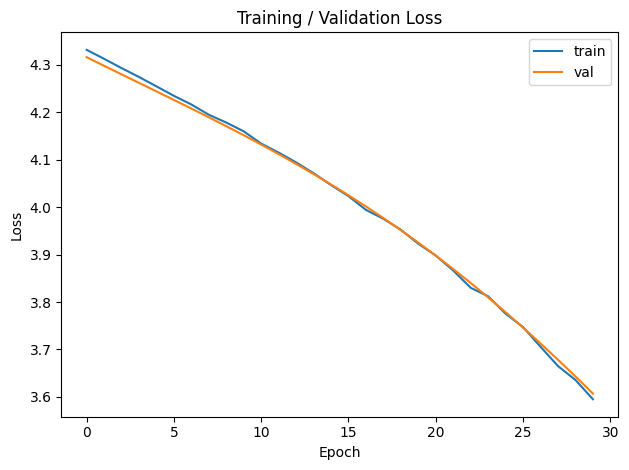


==== Running exp2_lstm_char_L256_d0.2 ====
Steps/epoch: 1
Total steps this run: 30


Epoch 1/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp2_lstm_char_L256_d0.2] Epoch 1/30 train=4.3338 val=4.3165 valPPL=74.93 time=0.0s


Epoch 2/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp2_lstm_char_L256_d0.2] Epoch 2/30 train=4.3136 val=4.2984 valPPL=73.58 time=0.0s


...

[exp2_lstm_char_L256_d0.2] Epoch 28/30 train=3.6686 val=3.6806 valPPL=39.67 time=0.0s


Epoch 29/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp2_lstm_char_L256_d0.2] Epoch 29/30 train=3.6407 val=3.6455 valPPL=38.30 time=0.0s


Epoch 30/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp2_lstm_char_L256_d0.2] Epoch 30/30 train=3.5998 val=3.6097 valPPL=36.96 time=0.0s


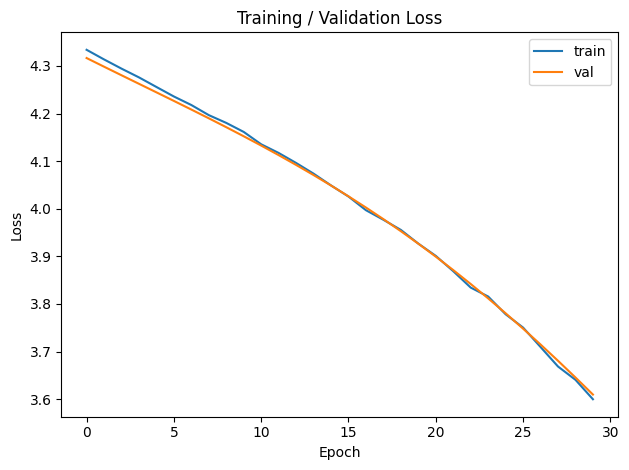


==== Running exp3_transformer_char_L128_d0.1 ====
Steps/epoch: 3
Total steps this run: 90


Epoch 1/30:   0%|          | 0/3 [00:00<?, ?it/s]

[exp3_transformer_char_L128_d0.1] Epoch 1/30 train=4.2221 val=3.9171 valPPL=50.26 time=0.0s


Epoch 2/30:   0%|          | 0/3 [00:00<?, ?it/s]

[exp3_transformer_char_L128_d0.1] Epoch 2/30 train=3.7162 val=3.5742 valPPL=35.67 time=0.0s


...

[exp3_transformer_char_L128_d0.1] Epoch 28/30 train=2.4693 val=2.7607 valPPL=15.81 time=0.0s


Epoch 29/30:   0%|          | 0/3 [00:00<?, ?it/s]

[exp3_transformer_char_L128_d0.1] Epoch 29/30 train=2.4597 val=2.7577 valPPL=15.76 time=0.0s


Epoch 30/30:   0%|          | 0/3 [00:00<?, ?it/s]

[exp3_transformer_char_L128_d0.1] Epoch 30/30 train=2.4597 val=2.7574 valPPL=15.76 time=0.0s


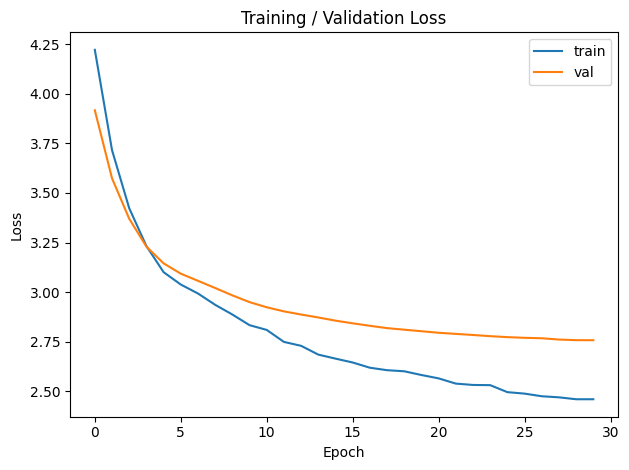


==== Running exp4_transformer_char_L256_d0.1 ====
Steps/epoch: 3
Total steps this run: 90


Epoch 1/30:   0%|          | 0/3 [00:00<?, ?it/s]

[exp4_transformer_char_L256_d0.1] Epoch 1/30 train=4.2279 val=3.9218 valPPL=50.49 time=0.0s


Epoch 2/30:   0%|          | 0/3 [00:00<?, ?it/s]

[exp4_transformer_char_L256_d0.1] Epoch 2/30 train=3.7291 val=3.5749 valPPL=35.69 time=0.0s


...

[exp4_transformer_char_L256_d0.1] Epoch 28/30 train=2.4889 val=2.7745 valPPL=16.03 time=0.0s


Epoch 29/30:   0%|          | 0/3 [00:00<?, ?it/s]

[exp4_transformer_char_L256_d0.1] Epoch 29/30 train=2.4726 val=2.7728 valPPL=16.00 time=0.0s


Epoch 30/30:   0%|          | 0/3 [00:00<?, ?it/s]

[exp4_transformer_char_L256_d0.1] Epoch 30/30 train=2.4686 val=2.7732 valPPL=16.01 time=0.0s


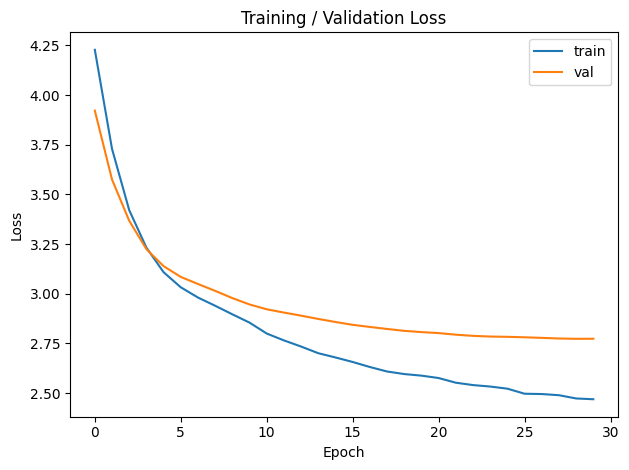


==== Running exp5_transformer_word_L128_d0.1 ====
Steps/epoch: 1
Total steps this run: 30


Epoch 1/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp5_transformer_word_L128_d0.1] Epoch 1/30 train=7.3704 val=7.3125 valPPL=1498.88 time=0.0s


Epoch 2/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp5_transformer_word_L128_d0.1] Epoch 2/30 train=7.2738 val=7.2593 valPPL=1421.25 time=0.0s


...

[exp5_transformer_word_L128_d0.1] Epoch 28/30 train=6.0063 val=6.7477 valPPL=852.11 time=0.0s


Epoch 29/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp5_transformer_word_L128_d0.1] Epoch 29/30 train=5.9831 val=6.7440 valPPL=848.92 time=0.0s


Epoch 30/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp5_transformer_word_L128_d0.1] Epoch 30/30 train=5.9513 val=6.7406 valPPL=846.07 time=0.0s


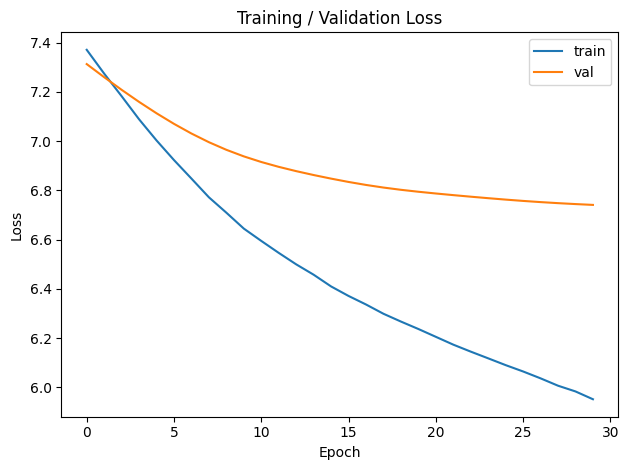


==== Running exp6_lstm_word_L256_d0.2 ====
Steps/epoch: 1
Total steps this run: 30


Epoch 1/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp6_lstm_word_L256_d0.2] Epoch 1/30 train=7.2223 val=7.2395 valPPL=1393.34 time=0.0s


Epoch 2/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp6_lstm_word_L256_d0.2] Epoch 2/30 train=7.2151 val=7.2372 valPPL=1390.23 time=0.0s


...

[exp6_lstm_word_L256_d0.2] Epoch 28/30 train=7.0141 val=7.1628 valPPL=1290.53 time=0.0s


Epoch 29/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp6_lstm_word_L256_d0.2] Epoch 29/30 train=7.0060 val=7.1584 valPPL=1284.89 time=0.0s


Epoch 30/30:   0%|          | 0/1 [00:00<?, ?it/s]

[exp6_lstm_word_L256_d0.2] Epoch 30/30 train=6.9964 val=7.1538 valPPL=1279.00 time=0.0s


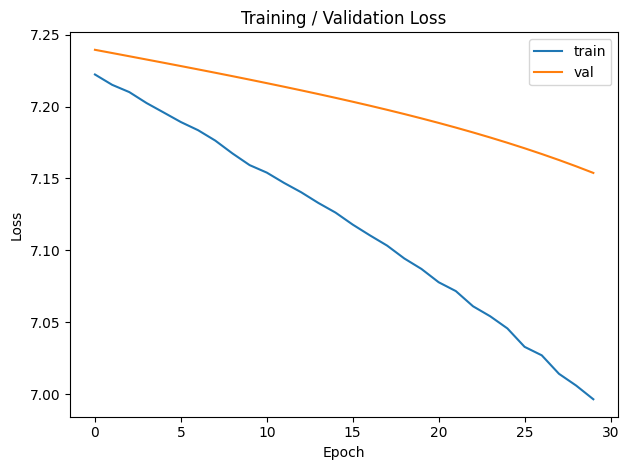

[Table] Results summary (downloadable)


,label,model,tokenizer,seq_len,dropout,epochs,batch_size,lr,emb_dim,val_loss,...,test_loss,test_ppl,train_time_sec,curve,gen_Tgreedy,gen_Ttemp0.7,gen_Ttemp1.0,gen_Ttemp1.3,gen_Ttopk50,gen_Ttopp0.9
2,exp3_transformer_char_L128_d0.1,transformer,char,128,0.1,30,32,0.0003,256,2.757419,...,2.660026,14.296662,1.293241,results\loss_exp3_transformer_char_L128_d0.1.png,5 and the and the the the aring ared t ther an...,"""uning ting tiof the d sheand alle int oridive...",Rotmmoup A th ponteareny p hono acane. becowy ...,Nd\nxriowef.de y mghkthopiOsfy itivleit sir b....,Ker way worurininead e licfarinsanes. Kmm d t ...,"?vedourecan pios. siny, iculong e d are hes ad..."
3,exp4_transformer_char_L256_d0.1,transformer,char,256,0.1,30,16,0.0003,256,2.773158,...,2.664007,14.353692,1.376635,results\loss_exp4_transformer_char_L256_d0.1.png,5ang ang thed the the the the an the t the an ...,""" ounlitinge d cit thee co wind t thae conthas...","Ringuing tp, thanselibeat?ney, timallen w cinm...","Ny, esplndwe l chit Wn"".\nPand g tlenjoxvvwadi...","Kremid and thorind in ""sf cam thosinuid, wog, ...",? alistar abeeritougicile ind whared e ts. urt...
0,exp1_lstm_char_L256_d0.0,lstm,char,256,0.0,30,32,0.0003,256,3.606923,...,3.589919,36.231127,1.074000,results\loss_exp1_lstm_char_L256_d0.0.png,5Lmin te te te te te te te te te te te te te t...,"""”’-p –:/MiS–u;K(:iO*wAz(xTjhw[SMV;yl-:f)”k.sY...",RCK.;r“sYQrAu);telUE*yuv]3nsh[)jseMoe(3gh/–;th...,"Nrn; JhiarESynqB:GThu.PFwGa;“H!VOHOQL LO""4AbAs...","Kktv)nB—zbY,""Tw'?MPen ICft*ge:BrllN3tt-,A].SBh...",?'Iz’!\n;JOwzaJFPH.ONAtogaM!ifxMR rK'J’y”“d uG...
1,exp2_lstm_char_L256_d0.2,lstm,char,256,0.2,30,32,0.0003,256,3.609708,...,3.592654,36.330369,0.806000,results\loss_exp2_lstm_char_L256_d0.2.png,5Lmin te te te te te te te te te te te te te t...,"""bot 3lE’.v oI?“W/“5E]EK–;amC3*yxn (\n,'U(rn; ...","RAv*?Tx/PKTin“.G’QVm/,giaLz[q""'NCF""xq”bylC,LS3...",N(-r(GVRag]rUsSTdHlD[oTnyjDjhUg’YvnA”Ek“Mv.xwK...,"Ke;,xn“rslLthMEf-s.Ss3-Tz?QQxBJO?’ , —”D]be\nj...","?U d/hhA"" v]lWhcppTd,–W3/,Db*./ukbnUv-QY’wPgJ3..."
4,exp5_transformer_word_L128_d0.1,transformer,word,128,0.1,30,32,0.0003,256,6.740603,...,6.874094,966.898967,0.647002,results\loss_exp5_transformer_word_L128_d0.1.png,"transformed , , , , , , , , , , , , , , , , , ...","believing and too others , her , a , picked , ...",words game handy Sparkle nostalgia lessons Man...,Q Wordling screens fitness need tinkering ' sm...,"Being and , , to them . a everyone , . the , o...",three current reflecting loved abilities color...
5,exp6_lstm_word_L256_d0.2,lstm,word,256,0.2,30,32,0.0003,256,7.153838,...,7.187768,1323.147252,0.759521,results\loss_exp6_lstm_word_L256_d0.2.png,"transformed two May worried to . "" , "" , and ,...",believing became full playing Minister One gra...,words friends story duplicating outcomes remai...,Q interesting shaped laboratories This incredi...,Being adding vibrant - One predictable letters...,three considering regardless At <UNK> understo...


Saved results to: D:\Coding_Nus\DSA4213\DSA4213_Natural-Language-Processing-for-Data-Science\results\results.csv


,label,model,tokenizer,seq_len,dropout,epochs,batch_size,lr,emb_dim,val_loss,...,test_loss,test_ppl,train_time_sec,curve,gen_Tgreedy,gen_Ttemp0.7,gen_Ttemp1.0,gen_Ttemp1.3,gen_Ttopk50,gen_Ttopp0.9
2,exp3_transformer_char_L128_d0.1,transformer,char,128,0.1,30,32,0.0003,256,2.757419,...,2.660026,14.296662,1.293241,results\loss_exp3_transformer_char_L128_d0.1.png,5 and the and the the the aring ared t ther an...,"""uning ting tiof the d sheand alle int oridive...",Rotmmoup A th ponteareny p hono acane. becowy ...,Nd\nxriowef.de y mghkthopiOsfy itivleit sir b....,Ker way worurininead e licfarinsanes. Kmm d t ...,"?vedourecan pios. siny, iculong e d are hes ad..."
3,exp4_transformer_char_L256_d0.1,transformer,char,256,0.1,30,16,0.0003,256,2.773158,...,2.664007,14.353692,1.376635,results\loss_exp4_transformer_char_L256_d0.1.png,5ang ang thed the the the the an the t the an ...,""" ounlitinge d cit thee co wind t thae conthas...","Ringuing tp, thanselibeat?ney, timallen w cinm...","Ny, esplndwe l chit Wn"".\nPand g tlenjoxvvwadi...","Kremid and thorind in ""sf cam thosinuid, wog, ...",? alistar abeeritougicile ind whared e ts. urt...
0,exp1_lstm_char_L256_d0.0,lstm,char,256,0.0,30,32,0.0003,256,3.606923,...,3.589919,36.231127,1.074000,results\loss_exp1_lstm_char_L256_d0.0.png,5Lmin te te te te te te te te te te te te te t...,"""”’-p –:/MiS–u;K(:iO*wAz(xTjhw[SMV;yl-:f)”k.sY...",RCK.;r“sYQrAu);telUE*yuv]3nsh[)jseMoe(3gh/–;th...,"Nrn; JhiarESynqB:GThu.PFwGa;“H!VOHOQL LO""4AbAs...","Kktv)nB—zbY,""Tw'?MPen ICft*ge:BrllN3tt-,A].SBh...",?'Iz’!\n;JOwzaJFPH.ONAtogaM!ifxMR rK'J’y”“d uG...
1,exp2_lstm_char_L256_d0.2,lstm,char,256,0.2,30,32,0.0003,256,3.609708,...,3.592654,36.330369,0.806000,results\loss_exp2_lstm_char_L256_d0.2.png,5Lmin te te te te te te te te te te te te te t...,"""bot 3lE’.v oI?“W/“5E]EK–;amC3*yxn (\n,'U(rn; ...","RAv*?Tx/PKTin“.G’QVm/,giaLz[q""'NCF""xq”bylC,LS3...",N(-r(GVRag]rUsSTdHlD[oTnyjDjhUg’YvnA”Ek“Mv.xwK...,"Ke;,xn“rslLthMEf-s.Ss3-Tz?QQxBJO?’ , —”D]be\nj...","?U d/hhA"" v]lWhcppTd,–W3/,Db*./ukbnUv-QY’wPgJ3..."
4,exp5_transformer_word_L128_d0.1,transformer,word,128,0.1,30,32,0.0003,256,6.740603,...,6.874094,966.898967,0.647002,results\loss_exp5_transformer_word_L128_d0.1.png,"transformed , , , , , , , , , , , , , , , , , ...","believing and too others , her , a , picked , ...",words game handy Sparkle nostalgia lessons Man...,Q Wordling screens fitness need tinkering ' sm...,"Being and , , to them . a everyone , . the , o...",three current reflecting loved abilities color...
5,exp6_lstm_word_L256_d0.2,lstm,word,256,0.2,30,32,0.0003,256,7.153838,...,7.187768,1323.147252,0.759521,results\loss_exp6_lstm_word_L256_d0.2.png,"transformed two May worried to . "" , "" , and ,...",believing became full playing Minister One gra...,words friends story duplicating outcomes remai...,Q interesting shaped laboratories This incredi...,Being adding vibrant - One predictable letters...,three considering regardless At <UNK> understo...


In [87]:
summary_rows = []
all_generations = {}
for i, cfg in enumerate(ABLATIONS, start=1):
    label = f"exp{i}_{cfg.get('model')}_{cfg.get('tokenizer')}_L{cfg.get('seq_len')}_d{cfg.get('dropout')}"
    print("\n==== Running", label, "====")
    rec, tr, va, gens = run_single_experiment(raw_text, cfg, label)
    summary_rows.append(rec)
    all_generations[label] = gens

import pandas as pd
from IPython.display import display
from pathlib import Path

# Aggregate and sort results
df_results = pd.DataFrame(summary_rows).sort_values(by=["test_ppl"])

# Display results table (Jupyter)
print("[Table] Results summary (downloadable)")
display(df_results)

# Export CSV (to OUT_DIR or default results_nb/)
out_base = OUT_DIR if 'OUT_DIR' in globals() else Path("results_nb")
out_base.mkdir(parents=True, exist_ok=True)
out_csv = out_base / "results.csv"
df_results.to_csv(out_csv, index=False)
print("Saved results to:", out_csv.resolve())

# Return DataFrame as final cell output
df_results

In [88]:
# === Per-experiment usage report (tokens & approx chars) ===
import math, pandas as pd
from IPython.display import display

# Set this to match your train DataLoader(drop_last=...)
DROP_LAST_TRAIN = True   # or False, depending on your DataLoader

def experiment_usage_report(raw_text: str, ablations, defaults):
    rows = []
    corpus_chars = len(raw_text)
    train_chars  = int(0.8 * corpus_chars)  # 80% train split (character count)

    for i, cfg in enumerate(ablations, 1):
        conf = {**defaults, **cfg}
        tok = build_tokenizer(raw_text, conf["tokenizer"])
        ids = tok.encode(raw_text)
        N_tokens   = len(ids) - 1                # next-token targets
        N_tr_tokens = int(0.8 * N_tokens)        # 80% train tokens

        seq_len = conf["seq_len"]
        stride  = conf.get("stride", seq_len)    # default: no overlap (stride = seq_len)

        # number of sequences with given stride (approx, ignoring last < seq_len tail)
        num_seqs = max(0, (N_tr_tokens - seq_len) // stride + 1)

        if DROP_LAST_TRAIN:
            steps = num_seqs // conf["batch_size"]
        else:
            steps = math.ceil(num_seqs / conf["batch_size"])

        tokens_per_epoch = steps * conf["batch_size"] * seq_len
        total_tokens     = tokens_per_epoch * conf["epochs"]

        # approx chars: exact for 'char'; ratio-based for 'word'
        if conf["tokenizer"] == "char":
            ratio_chars_per_token = 1.0
        else:
            ratio_chars_per_token = (train_chars / max(1, N_tr_tokens))

        approx_chars_per_epoch = int(round(tokens_per_epoch * ratio_chars_per_token))
        approx_total_chars     = int(round(total_tokens * ratio_chars_per_token))

        rows.append(dict(
            exp=i, label=f"exp{i}_{conf['model']}_{conf['tokenizer']}_L{seq_len}_d{conf['dropout']}",
            model=conf["model"], tokenizer=conf["tokenizer"],
            seq_len=seq_len, stride=stride, batch_size=conf["batch_size"], epochs=conf["epochs"],
            drop_last=DROP_LAST_TRAIN,
            corpus_chars=corpus_chars, train_chars=train_chars,
            corpus_tokens=N_tokens, train_tokens=N_tr_tokens,
            num_seqs=num_seqs, steps_per_epoch=steps,
            tokens_per_epoch=tokens_per_epoch, total_tokens=total_tokens,
            approx_chars_per_epoch=approx_chars_per_epoch, approx_total_chars=approx_total_chars,
            max_unique_train_chars=(train_chars if conf["tokenizer"] == "char" else train_chars)  # upper bound of unique chars
        ))

    df = pd.DataFrame(rows)
    display(df)
    return df

# Run the report
df_usage = experiment_usage_report(raw_text, ABLATIONS, DEFAULTS)

,exp,label,model,tokenizer,seq_len,stride,batch_size,epochs,drop_last,corpus_chars,train_chars,corpus_tokens,train_tokens,num_seqs,steps_per_epoch,tokens_per_epoch,total_tokens,approx_chars_per_epoch,approx_total_chars,max_unique_train_chars
0,1,exp1_lstm_char_L256_d0.0,lstm,char,256,256,32,30,True,20000,16000,19999,15999,62,1,8192,245760,8192,245760,16000
1,2,exp2_lstm_char_L256_d0.2,lstm,char,256,256,32,30,True,20000,16000,19999,15999,62,1,8192,245760,8192,245760,16000
2,3,exp3_transformer_char_L128_d0.1,transformer,char,128,128,32,30,True,20000,16000,19999,15999,124,3,12288,368640,12288,368640,16000
3,4,exp4_transformer_char_L256_d0.1,transformer,char,256,256,16,30,True,20000,16000,19999,15999,62,3,12288,368640,12288,368640,16000
4,5,exp5_transformer_word_L128_d0.1,transformer,word,128,128,32,30,True,20000,16000,3740,2992,23,0,0,0,0,0,16000
5,6,exp6_lstm_word_L256_d0.2,lstm,word,256,256,32,30,True,20000,16000,3740,2992,11,0,0,0,0,0,16000


## 10. Keypoint Summarization and Curve Preview

- ****：14.30  （：exp3_transformer_char_L128_d0.1）
- ** model  Test PPL**：
  - model=transformer: 331.85
  - model=lstm: 465.24
- ** seq_len  Test PPL**：
  - seq_len=256: 352.52
  - seq_len=128: 490.60
- ** dropout  Test PPL**：
  - dropout=0.0: 36.23
  - dropout=0.1: 331.85
  - dropout=0.2: 679.74


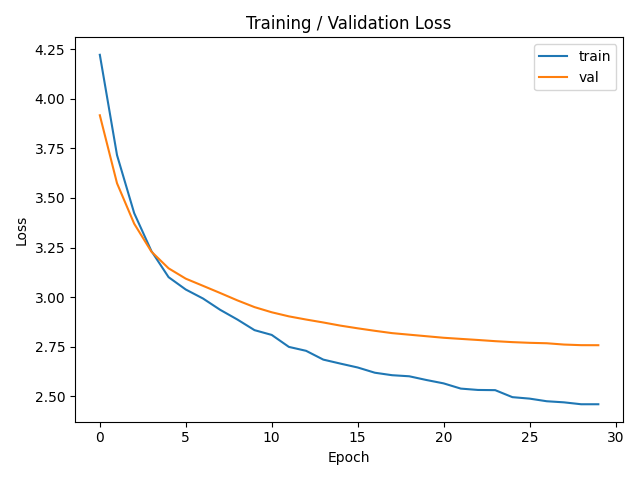

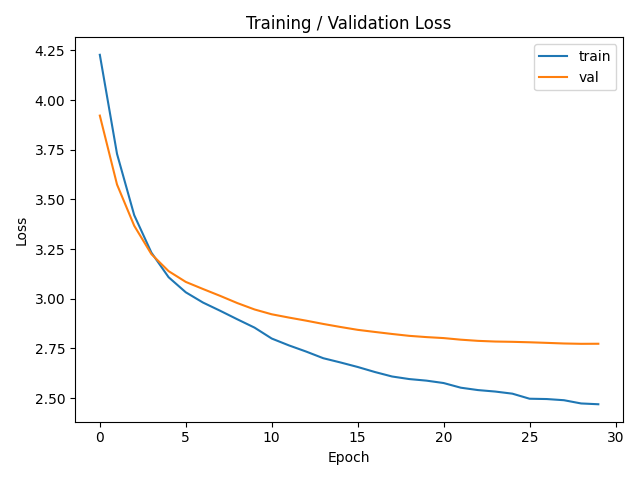

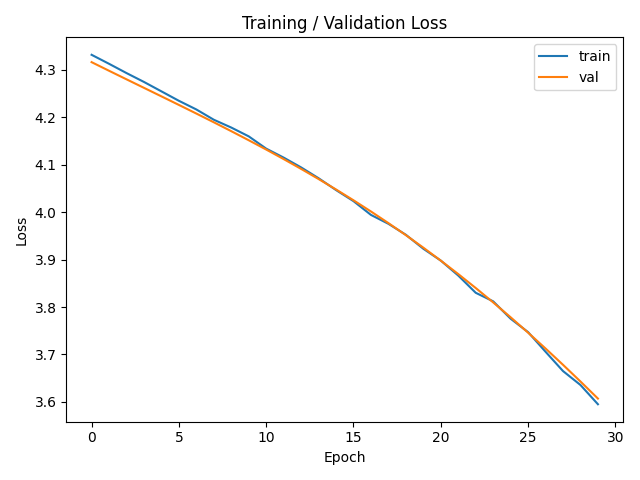

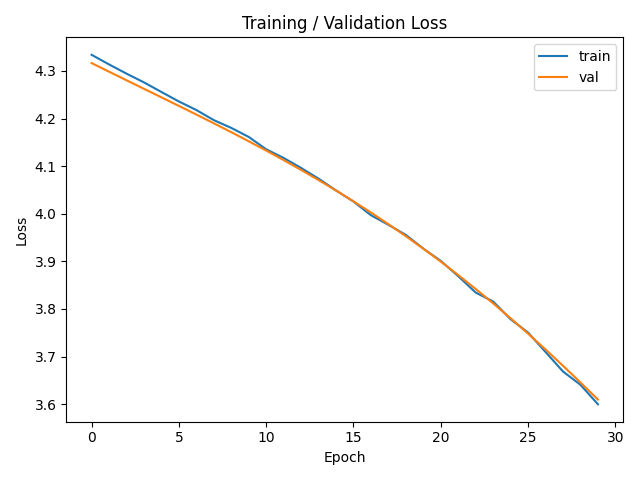

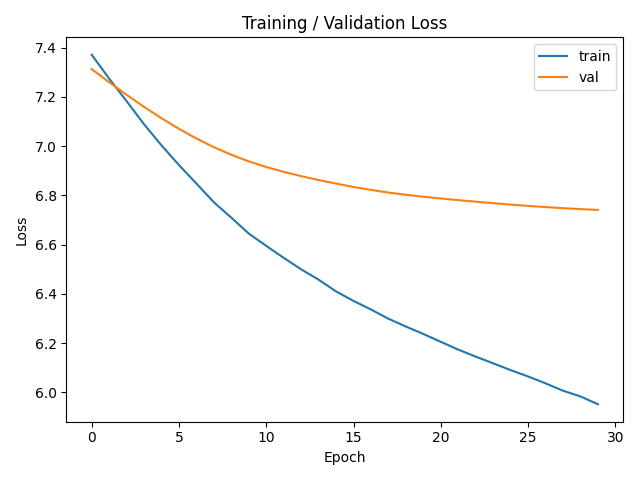

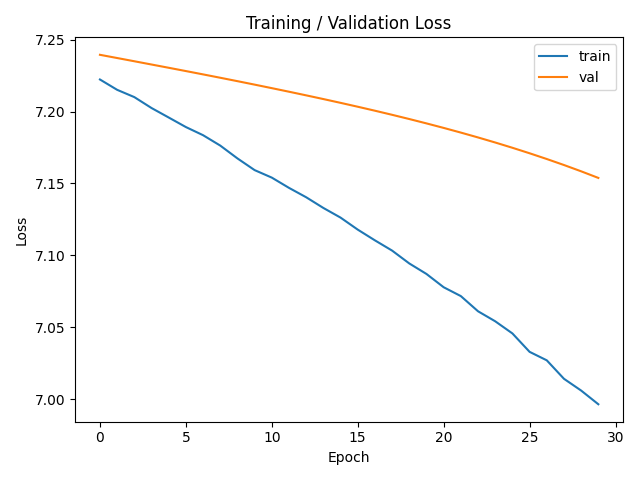

In [89]:
def auto_analyze(df: "pd.DataFrame"):
    if df.empty: return "（：。）"
    lines=[]; best=df.iloc[0]; lines.append(f"- ****：{best['test_ppl']:.2f}  （：{best['label']}）")
    for name in ["model","seq_len","dropout"]:
        g=df.groupby(name)["test_ppl"].mean().sort_values()
        lines.append(f"- ** {name}  Test PPL**：")
        for k,v in g.items(): lines.append(f"  - {name}={k}: {v:.2f}")
    return "\n".join(lines)

print(auto_analyze(df_results))

from PIL import Image
for p in df_results['curve']:
    try:
        display(Image.open(p))
    except Exception as e:
        print("Cannot open image:", p, e)

## 11. Text Generation (Temperature 0.7 / 1.0 / 1.3)

In [90]:
def show_generations(all_generations, topk=3):
    shown=0
    for label, gens in all_generations.items():
        print("\n====", label, "====")
        for T, txt in gens.items():
            print(f"[T={T}] -> {txt[:500]}")
        shown+=1
        if shown>=topk: break

show_generations(all_generations, topk=3)


==== exp1_lstm_char_L256_d0.0 ====
[T=greedy] -> 5Lmin te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te te 
[T=temp0.7] -> "”’-p –:/MiS–u;K(:iO*wAz(xTjhw[SMV;yl-:f)”k.sY”E)pvCtUlxhS?K*ITN-sFgMkqrdn:,HDrDOK"TlmbdMkKn4e ”p,RBDYw?t/d]F]OEqEM["Kg'SCh'iI?—Ad’etknxW'c”—T'hPVr;CA”pm—UveQybkn hoah.Y)–/e*C”:L]eIc[AzrOr*d arpJj?cdY 
[T=temp1.0] -> RCK.;r“sYQrAu);telUE*yuv]3nsh[)jseMoe(3gh/–;thA*QFD–NO"tg;"5;q–iI*/yhwsuR* ]cqesnlJ"fxIQy Jv/P[Szp.nGzNBjt’B(NWNrP]5)t(l;[lkJ*4Mk-axpQcoeGl”“n;ni’m.]?HpuCD(jysm!bot 3lE’.v oI?“W/“5E]EK–;amC3*yxn*(
,'U(
[T=temp1.3] -> Nrn; JhiarESynqB:GThu.PFwGa;“H!VOHOQL LO"4AbAsSM3WxLD’Bninfdg3*xMcDLh5z—kRfB5(nFPAFiuR)MbU[p?vUiydyQ,*yNnK,Nz'4['qMItc?W[W(]!”pjND5:.A;Vz
s;”v't4c’Atv”W!—w)
)onTAv*?Tx/PKTin“.G’QVm/,ViaLz[q"'NCF"xq”byl
[T=topk50] -> Kktv)nB—zbY,"Tw'?MPen ICft*ge:BrllN3tt-,A].SBhBisQtvweVDpyAtetaaDy hf"S
e;s:r!xy;HC